In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

Please choose the total number of maps and a directory name for the created maps

In [1]:
#number of images
n = 30000
#directory of data

#name = "circle_maps2005_64"
#low_noise_map_dir = "circle_maps2505_64_n3"

multiple_circle_map_files = "3k_circle_maps2905_64"

# Making noisy images of random circles

In [4]:
#make circle defined by radius and offsets
def make_circle_map(map_size: int = 32, radius: float = 10, cx: float = 16, cy: float = 16):
    x = np.linspace(0, map_size-1, map_size)
    y = np.linspace(0, map_size-1, map_size)
    X, Y = np.meshgrid(x, y)
    Z = (((X-cx)**2 + (Y-cy)**2) <= radius**2).astype(int)
    return Z

#make multiple circle maps with random radii and offsets + documenting circle on each map
def make_random_circle_maps(n: int = 1, map_size: int = 32, radius_mean: float = 10, radius_var: float = 0, radius_min: float = 2, 
                            cx_mean: float = 16, cx_var: float = 0, cy_mean: float = 16, cy_var: float = 0, max_shift: float = 10, seed: int = 42):
    rng = np.random.default_rng(seed)
    radii = rng.normal(radius_mean, radius_var, n).clip(min = radius_min)
    cx_shifts = rng.normal(cx_mean, cx_var, n).clip(max=max_shift)
    cy_shifts = rng.normal(cy_mean, cy_var, n).clip(max=max_shift)

    circle_images = np.zeros((n, map_size, map_size))
    doc = []
    for i in range(n):
        circle_images[i, :, :] = make_circle_map(map_size, radii[i], cx_shifts[i], cy_shifts[i])
        doc.append({"index": i, "radius": round(radii[i], 3), "cx_shift": round(cx_shifts[i], 3), "cy_shift": round(cy_shifts[i], 3)})

    return circle_images, doc

In [5]:
images, doc = make_random_circle_maps(n, 64, 10, 5, 2, 30, 10, 30, 10, 100, 42)

KeyboardInterrupt: 

In [ ]:
# fig, axes = plt.subplots(10, figsize=(40, 40))

# for i, ax in enumerate(axes):
#     ax.imshow(images[i, :, :])

# plt.tight_layout()
# plt.show()

In [ ]:
def make_noise_maps(n: int = 1, map_size: int = 32, noise_max: float = 10, seed: int = 42):
    noise_maps = np.zeros((n, map_size, map_size))
    rng = np.random.default_rng(seed)
    for i in range(n):
        noise_maps[i, :, :] = rng.uniform(0, noise_max, size=(map_size, map_size))

    return noise_maps

In [ ]:
noise_maps = make_noise_maps(n, 64, 3, 42)

In [ ]:
# fig, axes = plt.subplots(10, figsize=(40, 40))

# for i, ax in enumerate(axes):
#     ax.imshow(noise_maps[i, :, :])

# plt.tight_layout()
# plt.show()

In [ ]:
maps = noise_maps + images

In [ ]:
# fig, axes = plt.subplots(10, figsize=(40, 40))

# for i, ax in enumerate(axes):
#     ax.imshow(maps[i, :, :])

# plt.tight_layout()
# plt.show()

In [ ]:
def save_maps(maps, ground_truths, doc, file_name: str = "circle_maps"):
    radii = np.array([m["radius"] for m in doc])
    cx_shifts = np.array([m["cx_shift"] for m in doc])
    cy_shifts = np.array([m["cy_shift"] for m in doc])

    np.savez(file_name + ".npz", maps=maps, ground_truths=ground_truths, radii=radii, cx_shifts=cx_shifts, cy_shifts=cy_shifts)
    print("File saved as ", file_name, ".npz")
    return None

In [ ]:
save_maps(maps, images, doc, name)

File saved as  circle_maps2005_64 .npz


# Multiple circle images

In [ ]:
def make_multiple_circle_map(map_size: int = 32, number_circles: int = 1,  radius: list[float] = [10], cx: list[float] = [16], cy: list[float] = [16]):
    x = np.linspace(0, map_size-1, map_size)
    y = np.linspace(0, map_size-1, map_size)
    X, Y = np.meshgrid(x, y)
    Z_list = []
    for i in range(number_circles):
        Z = (((X-cx[i])**2 + (Y-cy[i])**2) <= radius[i]**2).astype(int)
        Z_list.append(Z)
    Z_final = sum(Z_list)
    return Z_final

def make_random_multiple_circle_maps(n: int = 1, map_size: int = 32, max_number_circles: int = 1, radius_mean: float = 10, radius_var: float = 0, radius_min: float = 2, 
                            cx_mean: float = 16, cx_var: float = 0, cy_mean: float = 16, cy_var: float = 0, max_shift: float = 10, seed: int = 42):
    rng = np.random.default_rng(seed)

    circle_images = np.zeros((n, map_size, map_size))
    doc = []

    for i in range(n):
        number_circles = rng.integers(1, max_number_circles, endpoint=True)

        radii = rng.normal(radius_mean, radius_var, number_circles).clip(min=radius_min)
        cx_shifts = rng.normal(cx_mean, cx_var, number_circles).clip(max=max_shift)
        cy_shifts = rng.normal(cy_mean, cy_var, number_circles).clip(max=max_shift)

        circle_images[i, :, :] = make_multiple_circle_map(map_size, number_circles, radii, cx_shifts, cy_shifts)
        doc.append({"index": i, "radius": radii, "cx_shift": cx_shifts, "cy_shift": cy_shifts})

    return circle_images, doc

In [ ]:
multiple_circles_test_maps, multiple_circles_test_doc = make_random_multiple_circle_maps(n, 64, 3, 10, 5, 5, 32, 30, 32, 30, 30, 42)

# fig, axes = plt.subplots(10, figsize=(40, 40))

# for i, ax in enumerate(axes):
#     ax.imshow(multiple_circles_test_maps[i, :, :])

# plt.tight_layout()
# plt.show()

In [ ]:
def make_noise_maps(n: int = 1, map_size: int = 32, noise_max: float = 10, seed: int = 42):
    noise_maps = np.zeros((n, map_size, map_size))
    rng = np.random.default_rng(seed)
    for i in range(n):
        noise_maps[i, :, :] = rng.uniform(0, noise_max, size=(map_size, map_size))

    return noise_maps

In [ ]:
noise_maps = make_noise_maps(n, 64, 3, 42)

multiple_circles_test_maps_withNoise = noise_maps + multiple_circles_test_maps

# fig, axes = plt.subplots(10, figsize=(40, 40))

# for i, ax in enumerate(axes):
#     ax.imshow(multiple_circles_test_maps_withNoise[i, :, :])

# plt.tight_layout()
# plt.show()

In [ ]:
def save_maps(maps, ground_truths, doc, file_name: str = "circle_maps"):

    radii = [m["radius"] for m in doc]
    cx_shifts = [m["cx_shift"] for m in doc]
    cy_shifts = [m["cy_shift"] for m in doc]

    np.savez(file_name + ".npz", maps=maps, ground_truths=ground_truths, radii=np.array(radii, dtype=object), cx_shifts=np.array(cx_shifts, dtype=object), cy_shifts=np.array(cy_shifts, dtype=object), allow_pickle=True)
    print("File saved as ", file_name, ".npz")
    return None

In [ ]:
save_maps(multiple_circles_test_maps_withNoise, multiple_circles_test_maps, multiple_circles_test_doc, multiple_circle_map_files)

File saved as  3k_circle_maps2905_64 .npz


# Neural Network 1

In [ ]:
def load_npz(path: str):
    data = np.load(path, allow_pickle=True)
    print(f"Keys in {path}: {list(data.keys())}")
 
    X = data["maps"]
    Y = data["ground_truths"]
    y = np.column_stack([data["radii"], data["cx_shifts"], data["cy_shifts"]])
    
    print(f"Loaded  X: {X.shape}  Y: {Y.shape}  y: {y.shape}")
    return X, Y, y

In [ ]:
data, sol_maps, sol = load_npz(name + ".npz")

Keys in circle_maps2005_64.npz: ['maps', 'ground_truths', 'radii', 'cx_shifts', 'cy_shifts']
Loaded  X: (30000, 64, 64)  Y: (30000, 64, 64)  y: (30000, 3)


In [ ]:
#Network
class SimpleNet(nn.Module):
    def __init__(self, height: int, width: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(height * width, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        total_loss += loss_fn(model(X_batch), y_batch).item() * len(X_batch)
    return total_loss / len(loader.dataset)

In [ ]:
#Prep data
X_np, Y_np, y_np = load_npz(name + ".npz")          # (30000, H, W), (30000, 3)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

train_X, train_y = X[:28000], y[:28000]
test_X,  test_y  = X[28000:], y[28000:]          # remaining 2000

H, W = X.shape[1], X.shape[2]

Keys in circle_maps2005_64.npz: ['maps', 'ground_truths', 'radii', 'cx_shifts', 'cy_shifts']
Loaded  X: (30000, 64, 64)  Y: (30000, 64, 64)  y: (30000, 3)


In [ ]:
#training
BATCH_SIZE = 256

train_loader = DataLoader(TensorDataset(train_X, train_y),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_X,  test_y),
                          batch_size=BATCH_SIZE, shuffle=False)

EPOCHS = 50
LR     = 1e-3

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = SimpleNet(H, W).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
loss_fn   = nn.MSELoss()

print(f"Training on {device}  |  {H}×{W} maps  |  batch={BATCH_SIZE}  |  epochs={EPOCHS}\n")
print(f"{'Epoch':>6}  {'Train MSE':>10}  {'LR':>10}")
print("-" * 32)

for epoch in range(1, EPOCHS + 1):
    train_loss = train(model, train_loader, optimizer, loss_fn, device)
    scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f"{epoch:>6}  {train_loss:>10.6f}  {lr_now:>10.2e}")

Training on cuda  |  64×64 maps  |  batch=256  |  epochs=50

 Epoch   Train MSE          LR
--------------------------------
     1   96.093132    1.00e-03
     5   19.706107    1.00e-03
    10   10.962310    1.00e-03
    15    7.308416    5.00e-04
    20    5.546897    5.00e-04
    25    4.547887    5.00e-04
    30    3.636326    2.50e-04
    35    2.933110    2.50e-04
    40    2.514138    2.50e-04
    45    2.167718    1.25e-04
    50    1.854258    1.25e-04


In [ ]:
#test
test_loss = evaluate(model, test_loader, loss_fn, device)
print(f"\nTest MSE  : {test_loss:.6f}")
print(f"Test RMSE : {test_loss**0.5:.6f}")

# per-output breakdown
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        all_preds.append(model(X_batch.to(device)).cpu())
        all_targets.append(y_batch)

preds   = torch.cat(all_preds)
targets = torch.cat(all_targets)
labels  = ["radius", "cx_shift", "cy_shift"]

print("\nPer-output RMSE on test set:")
for i, name in enumerate(labels):
    rmse = ((preds[:, i] - targets[:, i]) ** 2).mean().sqrt().item()
    print(f"  {name:<10}: {rmse:.6f}")


Test MSE  : 16.579663
Test RMSE : 4.071813

Per-output RMSE on test set:
  radius    : 1.148493
  cx_shift  : 5.015931
  cy_shift  : 4.822903


In [ ]:
#random forward pass
idx      = torch.randint(len(test_X), (1,)).item()
sample_X = test_X[idx].unsqueeze(0).to(device)
sample_y = test_y[idx]                             # [radius, cx_shift, cy_shift]

model.eval()
with torch.no_grad():
    pred = model(sample_X).squeeze(0).cpu()

In [ ]:
#get parameters
map_size = H                                       # H == W assumed square

r_true,  cx_true,  cy_true  = sample_y.tolist()
r_pred,  cx_pred,  cy_pred  = pred.tolist()

map_true = make_circle_map(map_size, radius=r_true, cx=cx_true, cy=cy_true)
map_pred = make_circle_map(map_size, radius=r_pred, cx=cx_pred, cy=cy_pred)

Sample index: 725

Output          Predicted   Ground Truth      Error
----------------------------------------------------
radius            11.8076        11.7390     0.0686
cx_shift          12.8311        11.5570     1.2741
cy_shift          32.1476        30.8630     1.2846


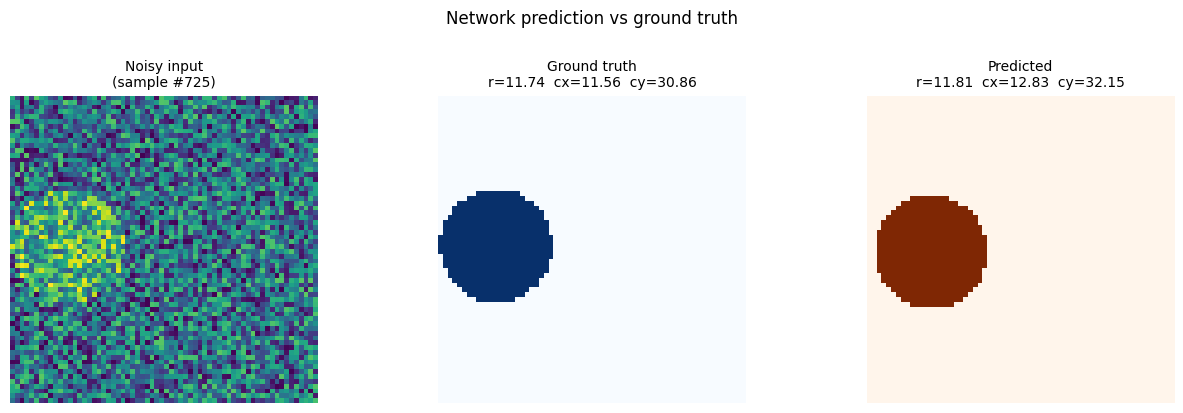

In [ ]:
#table
labels = ["radius", "cx_shift", "cy_shift"]
print(f"Sample index: {idx}\n")
print(f"{'Output':<12} {'Predicted':>12} {'Ground Truth':>14} {'Error':>10}")
print("-" * 52)
for name, p, t in zip(labels, pred, sample_y):
    print(f"{name:<12} {p.item():>12.4f} {t.item():>14.4f} {abs(p-t).item():>10.4f}")

#plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

panels = [
    (test_X[idx].numpy(), "viridis", f"Noisy input\n(sample #{idx})"),
    (map_true,            "Blues",   f"Ground truth\nr={r_true:.2f}  cx={cx_true:.2f}  cy={cy_true:.2f}"),
    (map_pred,            "Oranges", f"Predicted\nr={r_pred:.2f}  cx={cx_pred:.2f}  cy={cy_pred:.2f}"),
]

for ax, (data, cmap, title) in zip(axes, panels):
    ax.imshow(data, cmap=cmap, origin="upper")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle("Network prediction vs ground truth", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# U-Net

In [ ]:
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 3
NUM_WORKERS = 1
IM_HEIGHT = 64
IM_WIDTH = 64

In [ ]:
def load_npz(path: str):
    data = np.load(path, allow_pickle=True)
    print(f"Keys in {path}: {list(data.keys())}")
 
    X = data["maps"]
    Y = data["ground_truths"]
    y = np.column_stack([data["radii"], data["cx_shifts"], data["cy_shifts"]])
    
    print(f"Loaded  X: {X.shape}  Y: {Y.shape}  y: {y.shape}")
    return X, Y, y

In [ ]:
data, sol, paras = load_npz(multiple_circle_map_files + ".npz")

#sol_maps = np.zeros((n, 64, 64))
#for i in range(n):
#    sol_maps[i, :, :] = make_circle_map(64, sol[i, 0], sol[i, 1], sol[i, 2])

data_tensor = torch.from_numpy(data).float().unsqueeze(1)
sol_tensor = torch.from_numpy(sol).float().unsqueeze(1)
dataset = TensorDataset(data_tensor, sol_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Keys in 3k_circle_maps2905_64.npz: ['maps', 'ground_truths', 'radii', 'cx_shifts', 'cy_shifts']
Loaded  X: (30000, 64, 64)  Y: (30000, 64, 64)  y: (30000, 3)


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
    
class UNET(nn.Module):
    def __init__(
            self, in_channels, out_channels,  features=[64, 128, 256, 512], 
    ):
        super(UNET, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride =2)

        #Down
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #Up
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):

        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[int(idx/2)]

            ###TODO: resizing to handle wrong image sizes due to flooring in maxpool layer

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

In [ ]:
model = UNET(in_channels=1, out_channels=1).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()  # or nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(NUM_EPOCHS):
    running_loss = 0

    for x, y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        #forward
        preds = model(x)
        loss = criterion(preds, y)

        #backwards
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss/len(dataloader)
    print("Epoch: ", epoch, " Loss: ", avg_loss)

print("Done!")

Epoch:  0  Loss:  -0.6771839330469569
Epoch:  1  Loss:  -2.2761770761728286
Epoch:  2  Loss:  -4.215417445981503
Done!


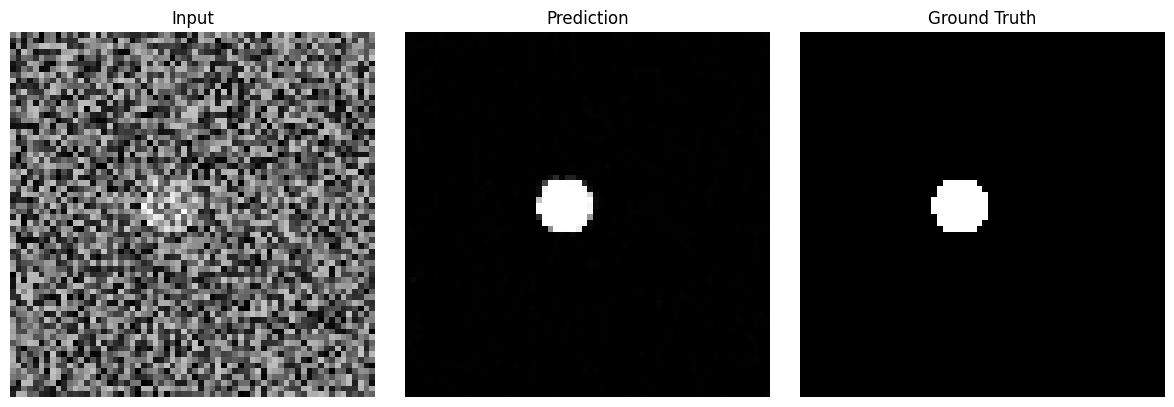

In [ ]:
model.eval()  # switch to eval mode
with torch.no_grad():  # no need to compute gradients for inference
    x, y = next(iter(dataloader))  # grab one batch
    x, y = x.to(DEVICE), y.to(DEVICE)
    preds = model(x)
    preds = torch.sigmoid(preds)  # convert logits to [0,1]

# Plot first image in the batch
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x[0].squeeze().cpu(), cmap="gray")
axes[0].set_title("Input")

axes[1].imshow(preds[0].squeeze().cpu(), cmap="gray")
axes[1].set_title("Prediction")

axes[2].imshow(y[0].squeeze().cpu(), cmap="gray")
axes[2].set_title("Ground Truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# GAN

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

In [3]:
DEVICE = 'cuda' if  torch.cuda.is_available() else 'cpu'
LR = 3e-4
IMG_DIM = 64
BATCH_SIZE = 16
EPOCHS = 3

In [4]:
class Discriminator(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)
    
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
    
class UNET_generator(nn.Module):
    def __init__(
            self, in_channels, out_channels,  features=[64, 128, 256, 512], 
    ):
        super(UNET_generator, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride =2)

        #Down
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        #Up
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):

        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[int(idx/2)]

            ###TODO: resizing to handle wrong image sizes due to flooring in maxpool layer

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

In [5]:
disc = Discriminator(IMG_DIM).to(DEVICE)
gen = UNET_generator(in_channels=1, out_channels=1).to(DEVICE)

In [6]:
def load_npz(path: str):
    data = np.load(path, allow_pickle=True)
    print(f"Keys in {path}: {list(data.keys())}")
 
    X = data["maps"]
    Y = data["ground_truths"]
    y = np.column_stack([data["radii"], data["cx_shifts"], data["cy_shifts"]])
    
    print(f"Loaded  X: {X.shape}  Y: {Y.shape}  y: {y.shape}")
    return X, Y, y

In [7]:
data, sol, paras = load_npz(multiple_circle_map_files + ".npz")

#sol_maps = np.zeros((n, 64, 64))
#for i in range(n):
#    sol_maps[i, :, :] = make_circle_map(64, sol[i, 0], sol[i, 1], sol[i, 2])

data_tensor = torch.from_numpy(data).float().unsqueeze(1)
sol_tensor = torch.from_numpy(sol).float().unsqueeze(1)
dataset = TensorDataset(data_tensor, sol_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Keys in 3k_circle_maps2905_64.npz: ['maps', 'ground_truths', 'radii', 'cx_shifts', 'cy_shifts']
Loaded  X: (30000, 64, 64)  Y: (30000, 64, 64)  y: (30000, 3)


In [8]:
opt_disc = optim.Adam(disc.parameters(), lr=LR)
opt_gen = optim.Adam(gen.parameters(), lr=LR)
loss = nn.BCEWithLogitsLoss()

In [9]:
real, _ = next(iter(dataloader))

In [10]:
# gen.train()
# disc.train()

# for epoch in range(EPOCHS):
#     for x, y in dataloader:
#         x, y = x.to(DEVICE), y.to(DEVICE)
#         noice = torch.randn_like(x).to(DEVICE)
#         #discrimitor
#         fake = gen(noice)
#         disc_real = disc(y).view(-1)
#         disc_fake = disc(fake).view(-1)
#         print(disc_real.shape)
#         print(disc_fake.shape)
#         lossD_real = loss(disc_real, torch.ones_like(disc_real))
#         lossD_fake = loss(disc_fake, torch.zeros_like(disc_fake))
#         lossD = (lossD_real + lossD_fake)/2
#         disc.zero_grad()
#         lossD.backward(retain_graph=True)
#         opt_disc.step()
#         #generator
#         out = disc(fake).view(-1)
#         lossG = loss(out, torch.ones_like(out))
#         gen.zero_grad()
#         lossG.backward()
#         opt_gen.step()

#         print("Epoch: " + str(epoch))
#         print("Loss D: " + str(lossD))

In [11]:
gen.train()
disc.train()

for epoch in range(EPOCHS):
    for x, y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        #generator
        preds = gen(x)
        loss_gen = loss(preds, y)

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        #discrimitor
        fake = gen(x)
        disc_real = disc(y).view(-1)
        disc_fake = disc(fake).view(-1)
        lossD_real = loss(disc_real, torch.ones_like(disc_real))
        lossD_fake = loss(disc_fake, torch.zeros_like(disc_fake))
        lossD = (lossD_real + lossD_fake)/2
        disc.zero_grad()
        lossD.backward(retain_graph=True)
        opt_disc.step()

        print("Epoch: " + str(epoch))
        print("Loss D: " + str(lossD))

Epoch: 0
Loss D: tensor(0.7239, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7222, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7204, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7163, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7122, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7057, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.7006, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6937, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6887, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6839, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6786, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6721, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6729, device='cuda:0', grad_fn=<DivBackward0>)
Epoch: 0
Loss D: tensor(0.6637, device='cuda:0', gr

AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


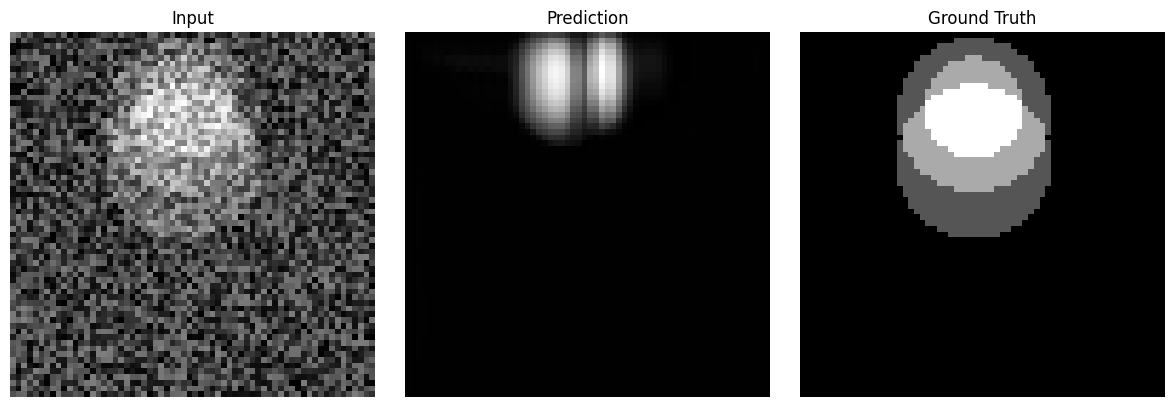

In [ ]:
gen.eval()  # switch to eval mode
with torch.no_grad():  # no need to compute gradients for inference
    x, y = next(iter(dataloader))  # grab one batch
    x, y = x.to(DEVICE), y.to(DEVICE)
    preds = gen(x)
    preds = torch.sigmoid(preds)  # convert logits to [0,1]

# Plot first image in the batch
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x[0].squeeze().cpu(), cmap="gray")
axes[0].set_title("Input")

axes[1].imshow(preds[0].squeeze().cpu(), cmap="gray")
axes[1].set_title("Prediction")

axes[2].imshow(y[0].squeeze().cpu(), cmap="gray")
axes[2].set_title("Ground Truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()